# Show Ensemble Training Metrics
Plot train/validation loss curves across ensemble sets with median and 16th-84th percentile bands.

In [11]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('mnras_mpl_stylefile')
%matplotlib inline
%config InlineBackend.figure_format='retina'

from lib.ensemble import SegmentationEnsemble

In [12]:
# Set your ensemble config here
CONFIG_PATH = 'configs/dice_full.toml'

ens = SegmentationEnsemble(config_path=CONFIG_PATH)
print('Loaded sets:', ens.sets)

Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Using device: mps
Channels per layer: [16, 32, 64, 128, 256, 256]
Model initialized with 6.89M parameters.
Loaded sets: ['set_0', 'set_1', 'set_2', 'set_3']


In [13]:
def _history_json(log_dir: Path) -> Path:
    hist = log_dir / 'training_history.json'
    if not hist.exists():
        raise FileNotFoundError(f'No training history JSON found in {log_dir}')
    return hist


def _load_ensemble_histories(ensemble: SegmentationEnsemble):
    train_series = []
    val_series = []
    set_names = []

    for model in ensemble.models:
        set_name = f'set_{model.set_id}'
        log_dir = Path(model.log_dir)
        hist_path = _history_json(log_dir)

        with open(hist_path, 'r', encoding='utf-8') as f:
            payload = json.load(f)

        hist = payload.get('history', [])
        if len(hist) == 0:
            raise ValueError(f'History is empty in {hist_path}')

        train = np.array([float(r['train_loss']) for r in hist], dtype=np.float64)
        val = np.array([float(r['val_loss']) for r in hist], dtype=np.float64)

        train_series.append(train)
        val_series.append(val)
        set_names.append(set_name)

        print(f'Loaded {set_name}: {len(hist)} epochs from {hist_path}')

    return set_names, train_series, val_series

In [14]:
set_names, train_series, val_series = _load_ensemble_histories(ens)

Loaded set_0: 1000 epochs from runs/dice_full/set_0/logs/training_history.json
Loaded set_1: 1000 epochs from runs/dice_full/set_1/logs/training_history.json
Loaded set_2: 1000 epochs from runs/dice_full/set_2/logs/training_history.json
Loaded set_3: 1000 epochs from runs/dice_full/set_3/logs/training_history.json


In [15]:
def _stack_with_nan(series_list):
    max_len = max(len(s) for s in series_list)
    arr = np.full((len(series_list), max_len), np.nan, dtype=np.float64)
    for i, s in enumerate(series_list):
        arr[i, :len(s)] = s
    return arr

train_arr = _stack_with_nan(train_series)
val_arr = _stack_with_nan(val_series)

epochs = np.arange(train_arr.shape[1])

train_p16 = np.nanpercentile(train_arr, 16, axis=0)
train_p50 = np.nanpercentile(train_arr, 50, axis=0)
train_p84 = np.nanpercentile(train_arr, 84, axis=0)

val_p16 = np.nanpercentile(val_arr, 16, axis=0)
val_p50 = np.nanpercentile(val_arr, 50, axis=0)
val_p84 = np.nanpercentile(val_arr, 84, axis=0)

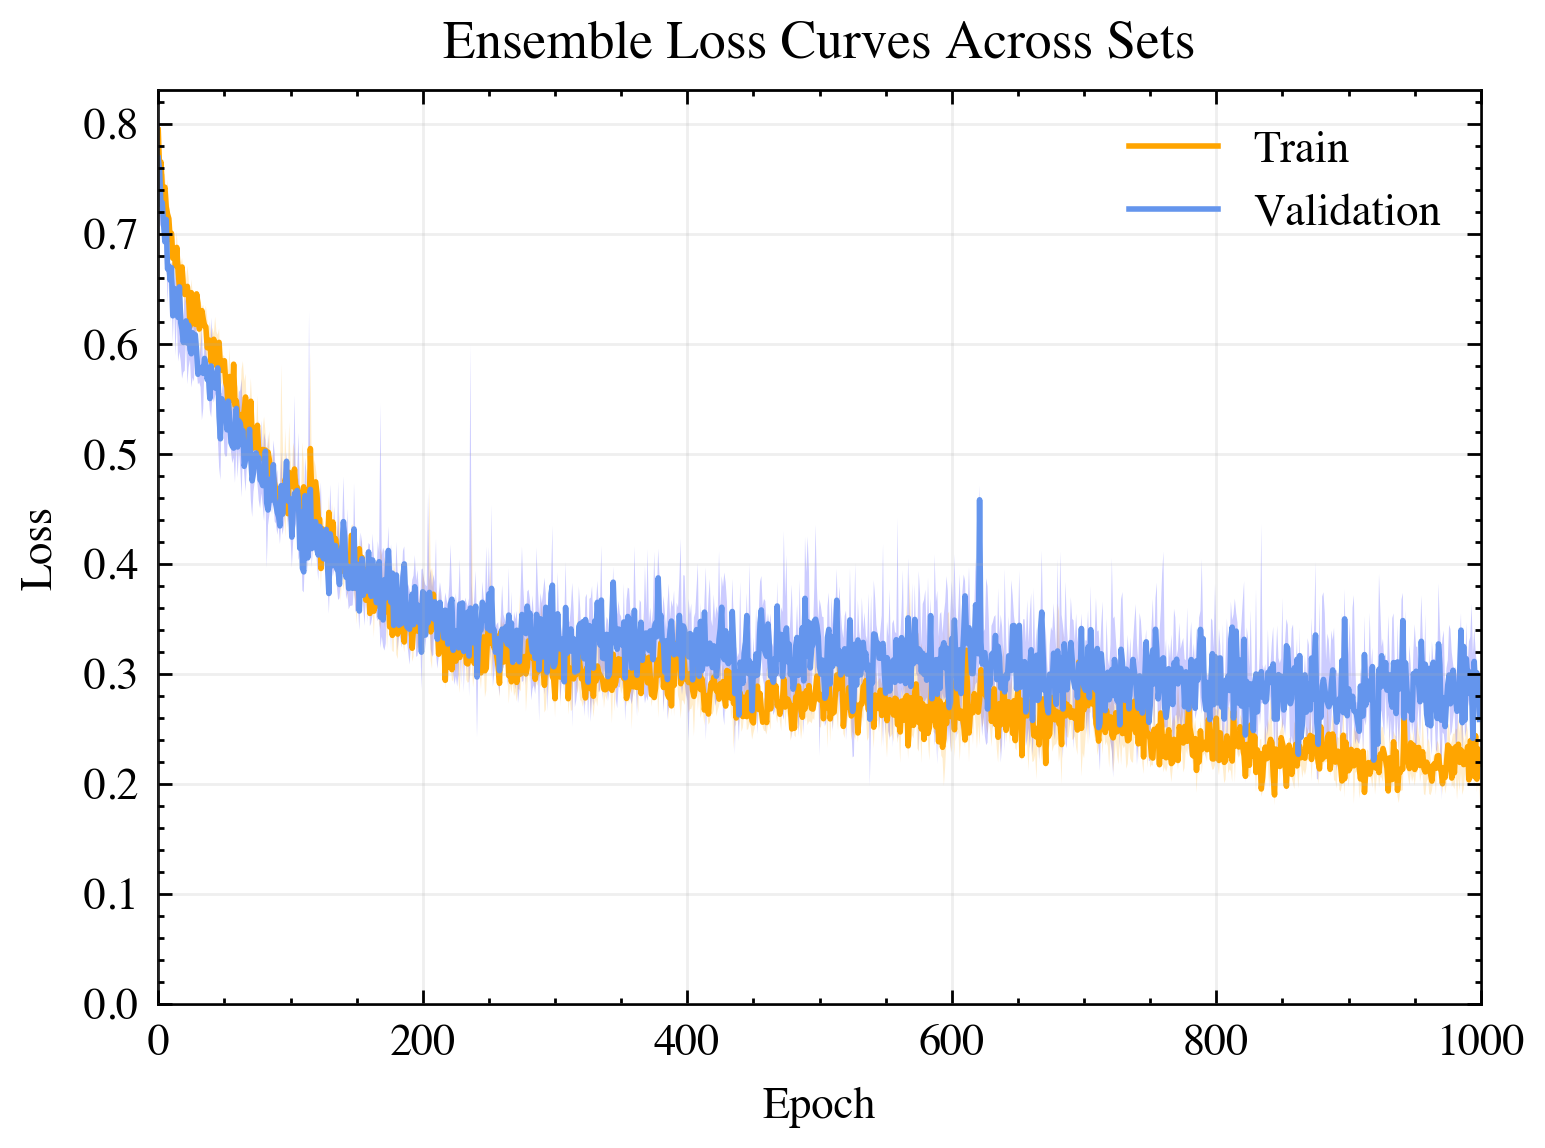

In [16]:
fig, ax = plt.subplots(figsize=(4, 3))

# Train
ax.fill_between(epochs, train_p16, train_p84, edgecolor='none', facecolor='orange', alpha=0.2, 
                 )
ax.plot(epochs, train_p50, color='orange', linewidth=1, 
         label='Train')

# Validation
ax.fill_between(epochs, val_p16, val_p84, edgecolor='none', facecolor='blue', alpha=0.2,
                 )
ax.plot(epochs, val_p50, color='cornflowerblue', linewidth=1, 
         label='Validation')

ax.set_xlim(0, len(epochs))
ax.set_ylim(bottom=0)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Ensemble Loss Curves Across Sets')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()